In [1]:
import Module
import pandas as pd
from enum import Enum
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
features_list = [
    "I01","I02","I03","I04","I05","I06","I07","I08","I09",
    "S01","S02","S03","S04","S05","S06","S07","S08","S09",
    "S10","S11","S12","S13","S14","S15","S16","S17","S18",
    "S19","S20","S21","S22"
]

In [3]:
dataset = pd.read_csv("dataset.csv")
mylabels = dataset["Target"]
myfeatures = dataset[features_list]

In [4]:
if Module.FEATURE_VIZ:
    Module.complete_comparison( # viewing the data in a web browser
        dataset, 
        "Optimal", 
        "MNS-TS", 
        "S18", 
        "S08", 
        "S06"
    )

In [5]:
if Module.FEATURE_VIZ:
    Module.mean_comparison(  # viewing the data in a web browser
        dataset, 
        "Optimal", 
        "MNS-TS", 
        "S18", 
        "S08", 
        "S06"
    )

In [6]:
# # TODO: example to perform training via Decision Tree
# from sklearn.model_selection import train_test_split
# x_train, x_test, y_train, y_test = train_test_split(
#     myfeatures.values, 
#     mylabels.values, 
#     test_size=0.3, 
#     random_state=1
# )
# Module.run_balance_classification(
#     x_train=x_train, 
#     y_train=y_train, 
#     x_test=x_test,
#     y_test=y_test, 
#     algorithm=Module.classifiers["Decision Tree"], 
#     max_iter=100, 
#     filename="testing_dt.pkl" # the filename of the trained model
# )

In [7]:
# directory that stores pickle files of the trained machine learning models
BASE_DIR = Path("mymodel")

In [8]:
class ModelName(str, Enum):
    DECISION_TREE = "Decision Tree"
    KNN = "KNN"
    RANDOM_FOREST = "Random Forest"
    GRADIENT_BOOSTING = "Gradient Boosting"
    XGBOOST = "XGBoost"
    LIGHTGBM = "LightGBM"

In [9]:
model_paths = {
    ModelName.DECISION_TREE: BASE_DIR / "decision_tree.pkl",
    ModelName.KNN: BASE_DIR / "knn_classifier.pkl",
    ModelName.RANDOM_FOREST: BASE_DIR / "random_forest.pkl",
    ModelName.GRADIENT_BOOSTING: BASE_DIR / "gradient_boosting.pkl",
    ModelName.XGBOOST: BASE_DIR / "extreme_gradient_boosting.pkl",
    ModelName.LIGHTGBM: BASE_DIR / "light_gradient_boosting.pkl",
}

evaluator = Module.ModelEvaluator(
    myfeatures, 
    mylabels
)

In [10]:
model_paths

{<ModelName.DECISION_TREE: 'Decision Tree'>: WindowsPath('mymodel/decision_tree.pkl'),
 <ModelName.KNN: 'KNN'>: WindowsPath('mymodel/knn_classifier.pkl'),
 <ModelName.RANDOM_FOREST: 'Random Forest'>: WindowsPath('mymodel/random_forest.pkl'),
 <ModelName.GRADIENT_BOOSTING: 'Gradient Boosting'>: WindowsPath('mymodel/gradient_boosting.pkl'),
 <ModelName.XGBOOST: 'XGBoost'>: WindowsPath('mymodel/extreme_gradient_boosting.pkl'),
 <ModelName.LIGHTGBM: 'LightGBM'>: WindowsPath('mymodel/light_gradient_boosting.pkl')}

In [11]:
results = evaluator.evaluate_models(model_paths) # evaluate all models

Evaluating Decision Tree...
Precision score : 0.5372
Recall score    : 0.5383
F1 score        : 0.5377

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.53      0.53      2981
           1       0.54      0.54      0.54      3019

    accuracy                           0.53      6000
   macro avg       0.53      0.53      0.53      6000
weighted avg       0.53      0.53      0.53      6000

Evaluating KNN...
Precision score : 0.4757
Recall score    : 0.3508
F1 score        : 0.4038

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.61      0.54      2981
           1       0.48      0.35      0.40      3019

    accuracy                           0.48      6000
   macro avg       0.48      0.48      0.47      6000
weighted avg       0.48      0.48      0.47      6000

Evaluating Random Forest...
Precision score : 0.5232
Recall score    : 0.5002
F1 score        : 0.5114

In [ ]:
# get best model (hihest F1 score)
best_model, largest_f1_score = evaluator.get_max_f1_score(results)
print(
    best_model, ": F1 score =", largest_f1_score
)

Gradient Boosting : F1 score = 0.6663326653306614


In [13]:
interpreter = Module.ShapInterpreter(
    model_path=model_paths[ModelName(best_model)],
    features=myfeatures
)

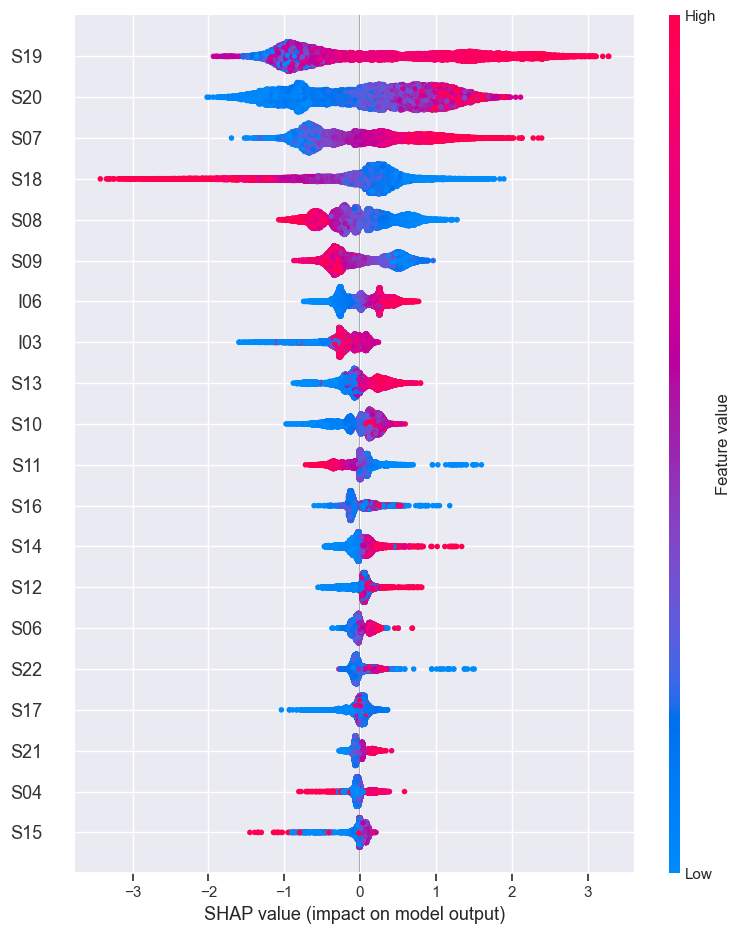

In [14]:
interpreter.summary_plot()

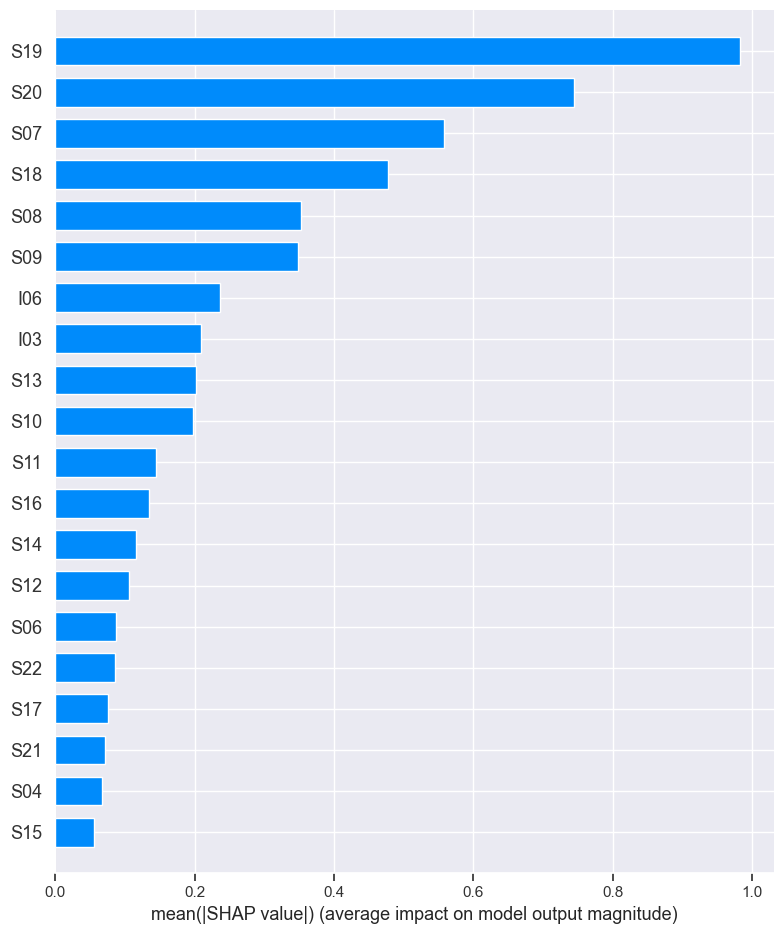

In [15]:
interpreter.summary_bar_plot()

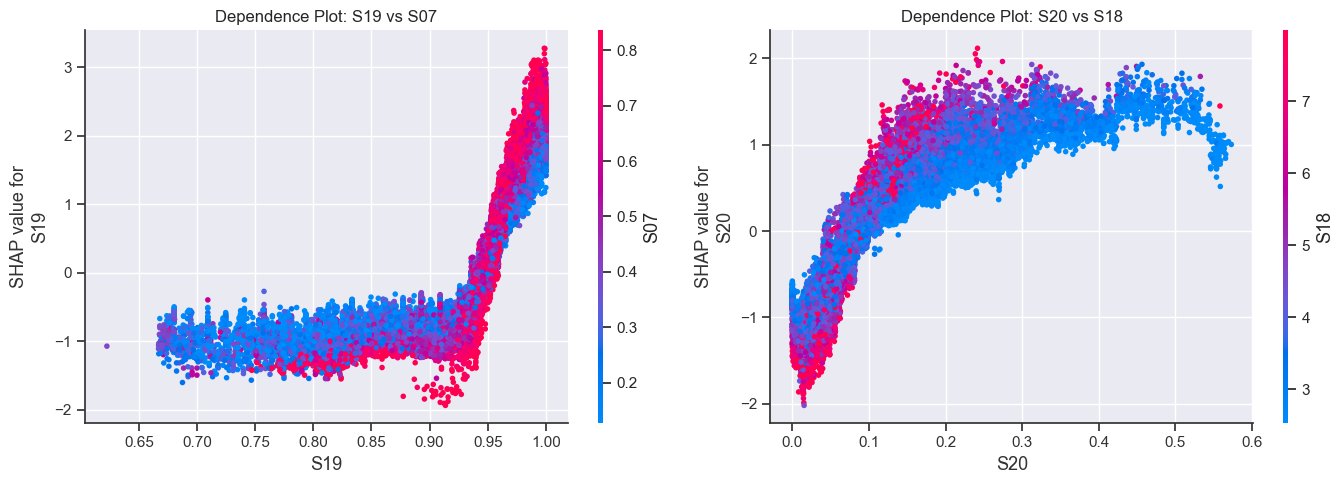

In [16]:
interpreter.dependence_plots([
    {"feature": "S19", "interaction": "S07"},
    {"feature": "S20", "interaction": "S18"}
])